In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



#Paramètres
VALUATION_DATE = "2025-12-31"

LOOKBACK_DAYS = 500

CONFIDENCE_LEVELS = [0.95, 0.99]


#Definition du portefeuille


weights = pd.Series({
    "SP500": 0.25,
    "EUROSTOXX50": 0.15,
    "NASDAQ100": 0.10,
    "UST10Y": 0.15,
    "BUND10Y": 0.10,
    "GOLD": 0.10,
    "OIL": 0.10,
    "EURUSD": 0.05
})

#Valeur totale du portefeuille à la date de valorisation
portfolio_value = 1_000_000

# Expositions actuelles
market_values = weights * portfolio_value

In [53]:
import yfinance as yf

# Tickers des actifs du portefeuille
tickers = {
    "SP500": "^GSPC",
    "EUROSTOXX50": "^STOXX50E",
    "NASDAQ100": "^NDX",
    "UST10Y": "IEF",
    "BUND10Y": "EXX6.DE",
    "GOLD": "GC=F",
    "OIL": "CL=F",
    "EURUSD": "EURUSD=X"
}

# Téléchargement des données historiques
data = yf.download(
    list(tickers.values()),
    start="2020-01-01",
    end="2025-12-31",
    auto_adjust=False,
    progress=False
)

# Récupération des prix de clôture
prices = data["Close"]

# Remplacement des tickers par les noms des actifs
prices = prices.rename(
    columns={ticker: name for name, ticker in tickers.items()}
)

# Classement chronologique
prices = prices.sort_index()
prices=prices.dropna()

# Aperçu des données
print("Aperçu des données :")
print(prices.head())


Aperçu des données :
Ticker            OIL    EURUSD     BUND10Y         GOLD      UST10Y  \
Date                                                                   
2020-01-03  63.049999  1.117144  199.529999  1549.199951  111.470001   
2020-01-06  63.270000  1.116196  199.285004  1566.199951  111.349998   
2020-01-07  62.700001  1.119799  199.115005  1571.800049  111.190002   
2020-01-08  59.610001  1.115474  198.065002  1557.400024  110.930000   
2020-01-09  59.560001  1.111321  196.889999  1551.699951  111.010002   

Ticker            SP500    NASDAQ100  EUROSTOXX50  
Date                                               
2020-01-03  3234.850098  8793.900391  3773.370117  
2020-01-06  3246.280029  8848.519531  3752.520020  
2020-01-07  3237.179932  8846.450195  3759.250000  
2020-01-08  3253.050049  8912.370117  3772.560059  
2020-01-09  3274.699951  8989.629883  3795.879883  


In [50]:
# controler s'il y a des actifs manquants


required_assets = weights.index.tolist()

missing_assets = [asset for asset in required_assets if asset not in prices.columns ]
if missing_assets:
    raise ValueError(f"Actifs manquants dans le fichier de prix : {missing_assets}")


In [57]:
# Filtrage à la date de valorisation
valuation_date = pd.Timestamp(VALUATION_DATE)
prices = prices.loc[ prices.index <= valuation_date, required_assets]
if prices.empty:
    raise ValueError("Aucune donnée disponible avant la date de valorisation.")


In [58]:
#Calcul de rendements historiques
returns = prices.pct_change().dropna()

# On ne conserve que la fenêtre historique choisie
if len(returns) > LOOKBACK_DAYS:
    returns = returns.tail(LOOKBACK_DAYS)

print("\nNombre de scénarios historiques :")
print(len(returns))
returns



Nombre de scénarios historiques :
500


Ticker,SP500,EUROSTOXX50,NASDAQ100,UST10Y,BUND10Y,GOLD,OIL,EURUSD
Date,,,,,,,,
2023-12-05,-0.000569,0.008566,0.002402,0.007047,0.000000,-0.002767,-0.009858,-0.004628
2023-12-06,-0.003906,0.006847,-0.005647,0.004135,0.000000,0.005945,-0.040653,-0.004069
2023-12-07,0.007968,-0.002117,0.014849,-0.001478,0.033085,-0.000295,-0.000577,-0.002498
2023-12-08,0.004095,0.011073,0.003882,-0.006451,-0.010498,-0.015567,0.027257,0.002363
2023-12-11,0.003924,0.003732,0.008520,0.000106,0.000769,-0.010159,0.001263,-0.002444
...,...,...,...,...,...,...,...,...
2025-12-19,0.008818,0.003246,0.013062,-0.005477,-0.008030,0.005047,0.009083,-0.001419
2025-12-22,0.006436,-0.002892,0.004558,-0.001039,0.000176,0.019076,0.023826,-0.001499
2025-12-23,0.004550,0.000973,0.004954,-0.000416,0.007214,0.008595,0.006378,0.004942


In [59]:
# Examen des rendements
print("\nStatistiques des rendements :")
print(returns.describe())


Statistiques des rendements :
Ticker       SP500  EUROSTOXX50   NASDAQ100      UST10Y     BUND10Y  \
count   500.000000   500.000000  500.000000  500.000000  500.000000   
mean      0.000873     0.000590    0.001038    0.000068   -0.000185   
std       0.010029     0.009540    0.013330    0.004130    0.006795   
min      -0.059750    -0.048069   -0.060674   -0.014260   -0.039155   
25%      -0.002961    -0.004193   -0.004328   -0.002525   -0.004205   
50%       0.001259     0.000752    0.001625    0.000157   -0.000241   
75%       0.005682     0.006440    0.007732    0.002769    0.003910   
max       0.095154     0.042573    0.120223    0.016759    0.033085   

Ticker        GOLD         OIL      EURUSD  
count   500.000000  500.000000  500.000000  
mean      0.001605   -0.000274    0.000167  
std       0.011364    0.019377    0.004559  
min      -0.057352   -0.085680   -0.018418  
25%      -0.004159   -0.011247   -0.002337  
50%       0.002113    0.000146   -0.000181  
75%       0.00

In [39]:
# P&L actif par actif :
# P&L_i,t = exposition_i * rendement_i,t
asset_pnl = returns.mul(market_values, axis=1)

print("\nExemple de P&L par actif :")
print(asset_pnl.head())


Exemple de P&L par actif :
Ticker            SP500  EUROSTOXX50    NASDAQ100       UST10Y      BUND10Y  \
Date                                                                          
2023-12-05  -142.217432  1284.946235   240.156766  1057.121231     0.000000   
2023-12-06  -976.550702  1027.104902  -564.691989   620.293818     0.000000   
2023-12-07  1992.047266  -317.506009  1484.923297  -221.751944  3308.453213   
2023-12-08  1023.874467  1661.016509   388.205544  -967.640587 -1049.752634   
2023-12-11   981.123572   559.763180   851.990529    15.969351    76.868729   

Ticker             GOLD          OIL      EURUSD  
Date                                              
2023-12-05  -276.664970  -985.762886 -231.386417  
2023-12-06   594.500867 -4065.268880 -203.462162  
2023-12-07   -29.548170   -57.654824 -124.889887  
2023-12-08 -1556.725711  2725.709719  118.171873  
2023-12-11 -1015.865903   126.346109 -122.190108  


In [60]:
#Calcul de P&L du portefeuille
portfolio_pnl = asset_pnl.sum(axis=1)
print("\n P&L portefeuille :")
print(portfolio_pnl)


 P&L portefeuille :
Date
2023-12-05     946.192529
2023-12-06   -3568.074147
2023-12-07    6034.072942
2023-12-08    2342.859180
2023-12-11    1474.005459
                 ...     
2025-12-19    3715.216647
2025-12-22    5708.149198
2025-12-23    4182.268802
2025-12-29   -3038.659993
2025-12-30     875.791902
Length: 500, dtype: float64


In [63]:
#Fonction de l'historical VAR
def historical_var(pnl: pd.Series, confidence_level: float = 0.99) -> float:

    alpha = 1 - confidence_level

    pnl_quantile = pnl.quantile(alpha)

    var = -pnl_quantile

    return var

In [68]:
# Fonction Expected Shortfall

def historical_es(pnl: pd.Series,confidence_level: float = 0.99) -> float:

    alpha = 1 - confidence_level

    a = pnl.quantile(alpha)

    tail_losses = pnl[pnl <= a]
    es = -tail_losses.mean()

    return es

In [88]:
# CALCUL VAR et ES

results = []

for confidence in CONFIDENCE_LEVELS:
    var_value = historical_var(portfolio_pnl, confidence)
    es_value = historical_es( portfolio_pnl, confidence)
    results.append({
        "Confidence Level": confidence,
        "VaR": var_value,
        "ES": es_value,
        "VaR %": var_value / portfolio_value,
        "ES %": es_value / portfolio_value
        })


risk_results = pd.DataFrame(results)
print("\nRÉSULTATS HISTORICAL VAR & ES")
print(risk_results)



RÉSULTATS HISTORICAL VAR & ES
   Confidence Level           VaR            ES      VaR%       ES%
0              0.95   7608.813215  12616.837574  0.007609  0.012617
1              0.99  13651.402134  22793.879009  0.013651  0.022794


In [86]:
# AFFICHAGE FORMATÉ
print("\n==========================")
print("   HISTORICAL RISK REPORT")
print("==========================")

print(f"Valuation Date: {VALUATION_DATE}")

print(f"Portfolio Value: {portfolio_value:,.2f} €")

print(f"Historical Scenarios: {len(portfolio_pnl)}")

for confidence in CONFIDENCE_LEVELS:

    var_value = historical_var( portfolio_pnl, confidence)

    es_value = historical_es(portfolio_pnl, confidence)

    print(f"\nVaR {confidence:.0%}  : "
        f"{var_value:,.2f} €")

    print(f"VaR {confidence:.0%} %: "
        f"{var_value / portfolio_value:.2%}")

    print(f"ES {confidence:.0%}   : "
        f"{es_value:,.2f} €")

    print(f"ES {confidence:.0%} % : "
        f"{es_value / portfolio_value:.2%}")


   HISTORICAL RISK REPORT
Valuation Date: 2025-12-31
Portfolio Value: 1,000,000.00 €
Historical Scenarios: 500

VaR 95%  : 7,608.81 €
VaR 95% %: 0.76%
ES 95%   : 12,616.84 €
ES 95% % : 1.26%

VaR 99%  : 13,651.40 €
VaR 99% %: 1.37%
ES 99%   : 22,793.88 €
ES 99% % : 2.28%


In [91]:
# Pire scenario historique


worst_date = portfolio_pnl.idxmin()

worst_pnl = portfolio_pnl.loc[worst_date]

print("\n==============================")
print("   WORST HISTORICAL SCENARIO")
print("==============================")

print(f"Worst Date : {worst_date.date()}")

print(f"Worst P&L  : {worst_pnl:,.2f} €")


   WORST HISTORICAL SCENARIO
Worst Date : 2025-04-04
Worst P&L  : -35,837.09 €


In [100]:
# Contribution au pire scenario

worst_contributions = (asset_pnl.loc[worst_date].sort_values())

print("\nContributions par actif :")
print(worst_contributions)


Contributions par actif :
Ticker
SP500         -14937.401336
OIL            -7408.507089
EUROSTOXX50    -6892.925962
NASDAQ100      -6067.398763
GOLD           -2744.591540
UST10Y           420.599191
EURUSD           619.000848
BUND10Y         1174.134397
Name: 2025-04-04 00:00:00, dtype: float64


In [101]:
# Top 10 des pires scenarios


worst_10 = (
    portfolio_pnl
    .sort_values()
    .head(10)
)

print("\n10 pires scénarios :")
print(worst_10)




10 pires scénarios :
Date
2025-04-04   -35837.090255
2025-04-03   -28075.062273
2024-08-02   -21419.641865
2025-10-10   -14673.921588
2025-04-07   -13963.679065
2024-08-05   -13648.247821
2025-03-10   -13383.316697
2024-09-03   -13251.535566
2024-12-18   -12193.451039
2024-04-30   -12066.807444
dtype: float64


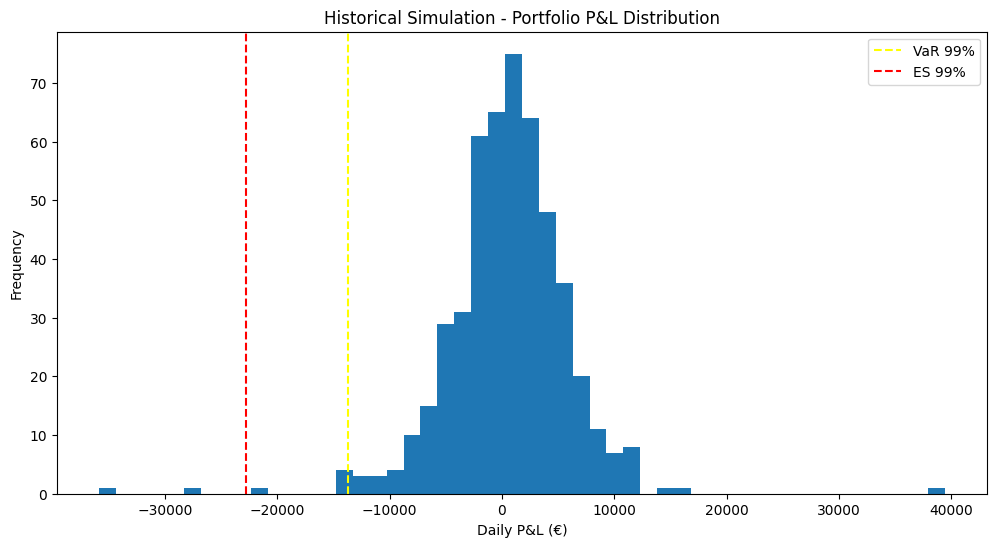

In [113]:
# Visualisation de la distribution du P&L
# Calcul de la VaR et de l'ES à 99 %
var_99 = historical_var(portfolio_pnl, 0.99)
es_99 = historical_es(portfolio_pnl, 0.99)

# Distribution historique des P&L
plt.figure(figsize=(12, 6))

plt.hist(portfolio_pnl, bins=50)

plt.axvline(-var_99,color="yellow", linestyle="--", label="VaR 99%")
plt.axvline(-es_99, color="red", linestyle="--", label="ES 99%")

plt.title("Historical Simulation - Portfolio P&L Distribution")
plt.xlabel("Daily P&L (€)")
plt.ylabel("Frequency")

plt.legend()
plt.show()


Cette figure représente la distribution historique des profits et pertes (PnL) journaliers du portefeuille. La majorité des observations est concentrée autour de 0 €, ce qui signifie que, lors des journées normales, les gains ou pertes du portefeuille restent relativement modérés. Cependant, la distribution présente quelques valeurs extrêmes, aussi bien négatives que positives, traduisant l'existence de journées de marché exceptionnelles.

La ligne jaune représente la VaR historique à 99 %, située autour de −14 000 €. Elle indique que, dans les conditions historiques observées, 99 % des pertes journalières ne dépassent pas environ 14 000 €; autrement dit, il reste environ 1 % des scénarios où la perte peut être supérieure à ce montant.

La ligne rouge représente l'Expected Shortfall (ES) à 99 %, autour de −23 000 €. L'ES mesure la perte moyenne lorsque la VaR à 99 % est dépassée. Le fait que l'ES soit nettement plus important que la VaR montre que, dans les scénarios les plus défavorables, les pertes peuvent devenir beaucoup plus importantes

Ainsi, la VaR donne un seuil de risque, tandis que l'Expected Shortfall permet de mieux mesurer la gravité des pertes extrêmes au-delà de ce seuil.

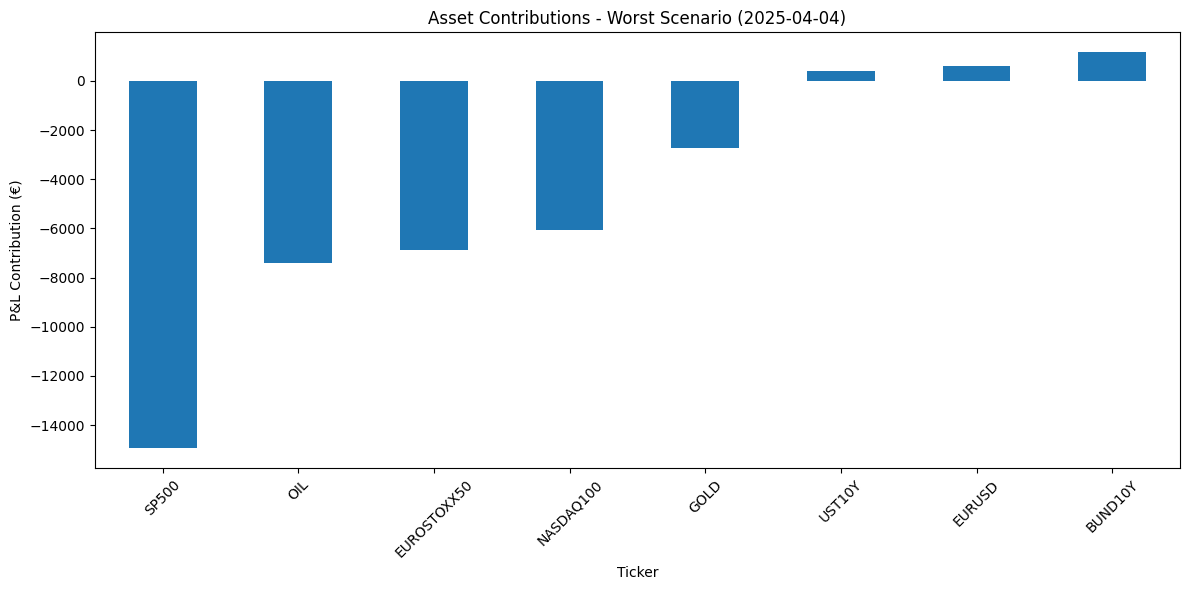

In [127]:
# Visualisation des contributions

worst_contributions.plot(kind="bar", figsize=(12, 6))

plt.title(f"Asset Contributions - Worst Scenario ({worst_date.date()})")
plt.ylabel("P&L Contribution (€)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Cette figure présente la **contribution de chaque actif au P&L du portefeuille lors du pire scénario observé, le 4 avril 2025**. On constate que la perte est principalement expliquée par les actifs risqués : le **S&P 500** est de loin le principal contributeur négatif, avec une perte d'environ **15 000 €**, suivi du **pétrole (OIL)**, de l'**EUROSTOXX50** et du **NASDAQ100**. L'**or (GOLD)** contribue également négativement, mais dans une proportion plus faible. À l'inverse, les positions **UST10Y, EURUSD et BUND10Y** affichent des contributions positives et permettent donc de **compenser partiellement les pertes** générées par les autres actifs. Cette figure met ainsi en évidence l’importance de la **diversification**: lors de ce scénario extrême, certaines positions jouent un rôle stabilisateur, mais leur contribution positive reste insuffisante pour neutraliser les fortes pertes provenant principalement des marchés actions.


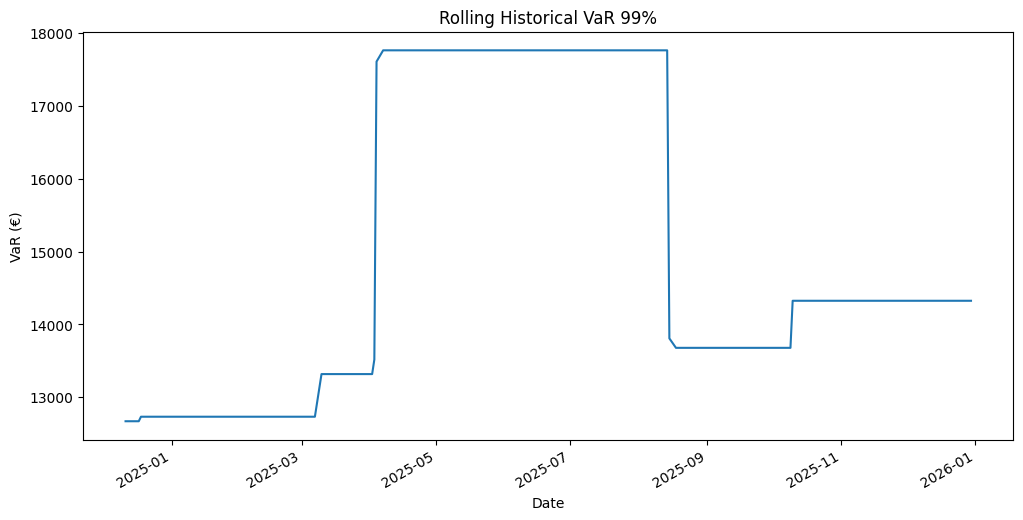

In [131]:
# ROLLING HISTORICAL VAR

# ROLLING HISTORICAL VAR

def rolling_historical_var(
    pnl: pd.Series,
    window: int = 250,
    confidence_level: float = 0.99
) -> pd.Series:

    alpha = 1 - confidence_level

    rolling_var = (
        pnl
        .rolling(window)
        .quantile(alpha)
        * -1
    )

    return rolling_var


rolling_var_99 = rolling_historical_var(
    portfolio_pnl,
    window=250,
    confidence_level=0.99
)


# VISUALISATION ROLLING VAR

plt.figure(figsize=(12, 6))

rolling_var_99.plot()

plt.title("Rolling Historical VaR 99%")
plt.ylabel("VaR (€)")
plt.xlabel("Date")

plt.show()

Le **Rolling Historical VaR** permet de suivre l'évolution du risque du portefeuille au cours du temps, contrairement à une VaR calculée sur l'ensemble de la période qui fournit une mesure plus statique. En utilisant une fenêtre glissante, ici de **250 observations**, la VaR est régulièrement recalculée à partir des données les plus récentes. Cette approche permet ainsi de détecter les périodes de forte volatilité et d'identifier les moments où le portefeuille devient plus exposé aux pertes importantes. Le Rolling VaR est donc particulièrement utile pour comprendre comment le niveau de risque évolue avec les conditions de marché et pour adapter la gestion du portefeuille en conséquence.
